# Predicting Recombination Rate with ResNet-18

In this tutorial, we demonstrate how to train a convolutional neural network (ResNet-18) to predict continuous population genetic parameters directly from binary alignment data.

### Workflow
1. **Simulation Setup**: Configure `MSPrimeSimulator` using an empirical recombination prior defined in `recom.ini`.
2. **Haplotype Alignment Transforms**: Polarize, seriate (order rows by similarity), and pad/crop alignments into fixed tensor shapes.
3. **On-the-Fly Simulation**: Wrap the simulation pipeline in `LiveSimulationDataset` to generate fresh training data continuously during training.
4. **Training**: Optimize ResNet-18 using Smooth L1 loss.
5. **Evaluation**: Compare true vs. predicted log recombination rates $\log(r)$ on holdout simulations.

We use the following config file to specify our prior:
```
[base]
mu = 1.5e-8
r = TruncatedExponential(a = 1e-8, b = 1e-6, lam = 4641167.677653745)
L = 200000
ploidy = 1

[samples]
# A diploid population with a variable size history defined by a spline
pop1 = {'N0': 'UniformFloatDiscrete([1e3, 2e3, 5e3, 1e4, 2e4, 5e4])', 'n': 32}
```

## 1. Imports and Environment Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from popgenml.data.simulators import MSPrimeSimulator
from popgenml.data.transforms import ORToolsSeriate, FastSeriate, PadCrop, Flip, Compose
from popgenml.data.datasets import LiveSimulationDataset
from popgenml.models.torchvision import resnet18

# Set compute device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/home/kilgoretrout/anaconda3/envs/pyg/lib/python3.10/site-packages/msprime/__init__.py:254: FutureWarning: 'msprime.TreeSequence' is deprecated and will be removed in future versions. Use 'tskit.TreeSequence'.
  warnings.warn(


Using device: cuda


## 2. Simulator Configuration & Data Preprocessing

We instantiate `MSPrimeSimulator` with `recom.ini`, compose a transformation pipeline to format alignments to fixed `(n, 128)` dimensions, and standardize the regression target $\log(r)$ using empirical prior statistics.

In [24]:
# 1. Initialize the simulation engine from the configuration file
simulator = MSPrimeSimulator('recom.ini')

# 2. Specify formatting transforms applied to each simulated alignment
pipeline = Compose([
    Flip(),             # Destroy perfect info about ancestral v derived alleles
    FastSeriate(),      # Spectral seriation: cluster similar haplotypes
    PadCrop(128)        # Pad or randomly crop segregating sites to length 128
])

# 3. Empirically compute mean and standard deviation of log(r) under the prior
prior_samples = simulator.r.rvs(size=10000)
log_samples = np.log(prior_samples)

mu_y = float(np.mean(log_samples))
std_y = float(np.std(log_samples))

print(f"Target prior log(r): mean = {mu_y:.4f}, std = {std_y:.4f}")

Target prior log(r): mean = -15.7791, std = 1.0152


## 3. Dataset & DataLoader

`LiveSimulationDataset` calls `simulator.simulate()` on demand. The `parse_fn` processes each simulation dictionary into:
- **Feature Tensor**: Haplotype matrix formatted to `(1, n_samples, 128)` for 2D convolution.
- **Label Tensor**: Standardized log recombination rate $z = \frac{\log(r) - \mu_y}{\sigma_y}$.

In [25]:
def parse_fn(result):
    x = result['x']      # Binary alignment matrix (n_samples, n_sites)
    pos = result['pos']  # Normalized site coordinates
    r = result['r']      # Recombination rate drawn for this simulation
    
    # Standardize regression target
    norm_r = (np.log(r) - mu_y) / std_y
    
    # Apply alignment seriation and pad/crop pipeline
    x, pos = pipeline(x, pos)
    
    # Add a channel dimension: (1, n_samples, 128)
    features = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
    target = torch.tensor([norm_r], dtype=torch.float32)
    
    return features, target

# Wrap into an on-the-fly streaming dataset
dataset = LiveSimulationDataset(simulator, parse_fn)

batch_size = 16
dataloader = DataLoader(dataset, batch_size=batch_size, num_workers=0)

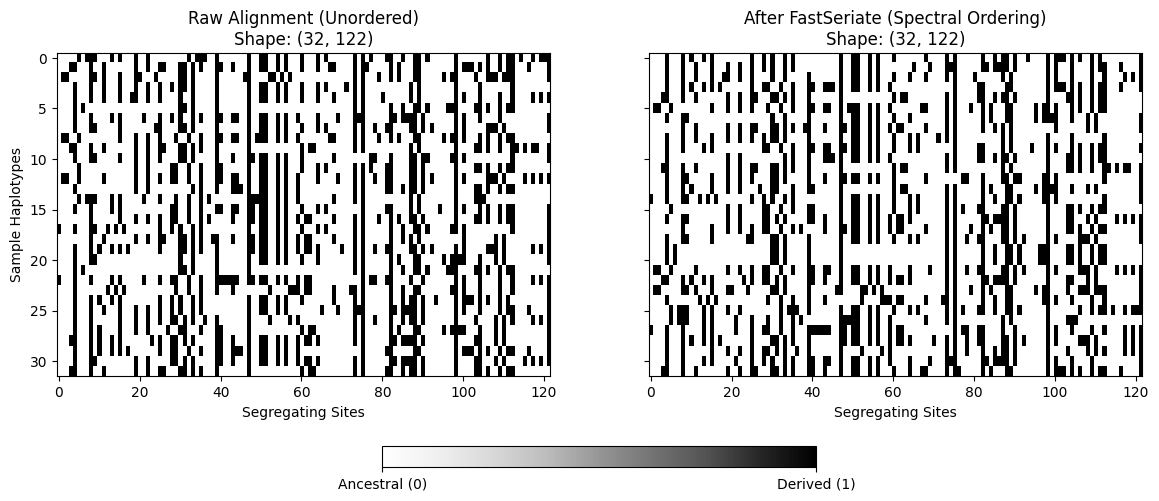

In [26]:
raw_sim = simulator.simulate()
raw_x = raw_sim['x'].copy()        # Shape: (n_samples, n_sites)
raw_pos = raw_sim['pos'].copy()

# Apply only FastSeriate to see the row ordering effect
seriator = FastSeriate(dist='cosine')
seriated_x, _ = seriator(raw_x.copy(), raw_pos)

# Plot before and after side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 1. Unordered raw alignment
im0 = axes[0].imshow(raw_x, aspect='auto', cmap='Greys', interpolation='nearest')
axes[0].set_title(f'Raw Alignment (Unordered)\nShape: {raw_x.shape}', fontsize=12)
axes[0].set_xlabel('Segregating Sites', fontsize=10)
axes[0].set_ylabel('Sample Haplotypes', fontsize=10)

# 2. Seriated alignment
im1 = axes[1].imshow(seriated_x, aspect='auto', cmap='Greys', interpolation='nearest')
axes[1].set_title(f'After FastSeriate (Spectral Ordering)\nShape: {seriated_x.shape}', fontsize=12)
axes[1].set_xlabel('Segregating Sites', fontsize=10)

# Add shared colorbar representing binary alleles (0: Ancestral, 1: Derived)
cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), orientation='horizontal', pad=0.15, shrink=0.4)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Ancestral (0)', 'Derived (1)'])

plt.show()

## 4. Model Architecture & Optimizer

We use a 1-channel `resnet18` adapted for single-channel genotype matrices, predicting a single scalar output ($k=1$).

In [28]:
model = resnet18(in_channels=1, num_classes=1).to(device)

criterion = nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 5
batches_per_epoch = 25  # Cap steps since live simulations generate indefinitely

print(model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## 5. Model Training

In [29]:
train_losses = []

from tqdm import tqdm

print("Starting Training...")
model.train()

for epoch in tqdm(range(epochs)):
    epoch_loss = 0.0
    data_iter = iter(dataloader)
    
    for batch_idx in range(batches_per_epoch):
        try:
            inputs, targets = next(data_iter)
        except StopIteration:
            break
            
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / batches_per_epoch
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch + 1}/{epochs}] - Loss (Smooth L1): {avg_loss:.4f}")

Starting Training...


 20%|█████████████████████████████▌                                                                                                                      | 1/5 [01:19<05:16, 79.14s/it]

Epoch [1/5] - Loss (Smooth L1): 0.6983


 40%|███████████████████████████████████████████████████████████▏                                                                                        | 2/5 [02:18<03:22, 67.53s/it]

Epoch [2/5] - Loss (Smooth L1): 0.4352


...

Epoch [3/5] - Loss (Smooth L1): 0.4242


 80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                             | 4/5 [04:17<01:00, 60.61s/it]

Epoch [4/5] - Loss (Smooth L1): 0.3517


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [05:27<00:00, 65.47s/it]

Epoch [5/5] - Loss (Smooth L1): 0.3563


## 6. Visualizing Training Loss & Validation Performance

We plot the training loss progression alongside a scatter plot of true versus predicted recombination rates on a holdout batch, unstandardized back to natural log space $\log(r)$.

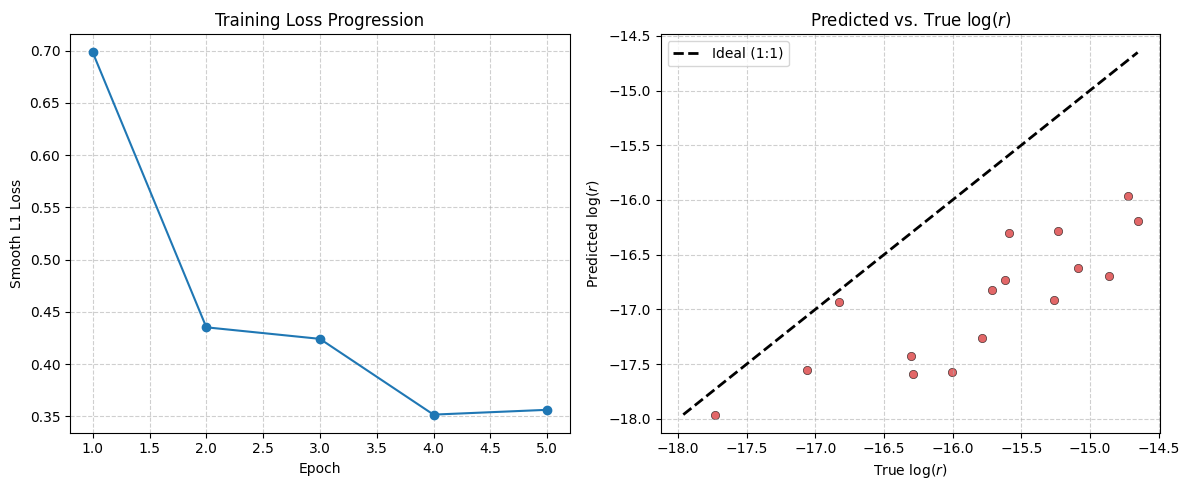

In [30]:
plt.figure(figsize=(12, 5))

# 1. Loss Progression
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, marker='o', linestyle='-', color='tab:blue')
plt.title('Training Loss Progression')
plt.xlabel('Epoch')
plt.ylabel('Smooth L1 Loss')
plt.grid(True, linestyle='--', alpha=0.6)

# 2. True vs. Predicted on Validation Batch
model.eval()
with torch.no_grad():
    sample_inputs, sample_targets = next(iter(dataloader))
    sample_inputs = sample_inputs.to(device)
    
    preds = model(sample_inputs).cpu().numpy()
    actuals = sample_targets.numpy()
    
    # Inverse transform to original log space
    preds_log = (preds * std_y) + mu_y
    actuals_log = (actuals * std_y) + mu_y

plt.subplot(1, 2, 2)
plt.scatter(actuals_log, preds_log, alpha=0.7, color='tab:red', edgecolors='k', linewidth=0.5)

# Plot identity line
min_val = min(actuals_log.min(), preds_log.min())
max_val = max(actuals_log.max(), preds_log.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ideal (1:1)')

plt.title('Predicted vs. True $\\log(r)$')
plt.xlabel('True $\\log(r)$')
plt.ylabel('Predicted $\\log(r)$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()